# ESA BIOMASS Data Access and Visualization (Token-secured)

Authors: Rajat Shinde (UAH), Alex Mandel (Development Seed), Sheyenne Kirkland (UAH), Harshini Girish (UAH), Jamison French (Development Seed), Henry Rodman (Development Seed), Chuck Daniels (Development Seed), Zac Deziel (Development Seed), Brian Freitag (NASA), Francesco Ferrante (SERCO), Cristiano Lopes (ESA)

Date: December 23, 2025

Description: This notebook documents how to access and visualize the ESA BIOMASS data hosted on the ESA MAAP server. It is an example illustrating data access from ESA server based on ESA MAAP Token using the NASA MAAP Authorization. 

---

## What you will do
1. Understand the product and file organization.  
2. Obtain an ESA data access offline token.  
3. Convert offline token to a short-lived data access token
4. Access the ESA BIOMASS Level 1a raster using the data access token.    
5. Visualize in Python.  

---

## Run this notebook
To access and run this tutorial within MAAP's Algorithm Development Environment (ADE), please refer to the [Getting started with the MAAP](https://docs.maap-project.org/en/latest/getting_started/getting_started.html) section of our documentation.

Disclaimer: it is highly recommended to run a tutorial within MAAP's ADE, which already includes packages specific to MAAP, such as maap-py. Running the tutorial outside of the MAAP ADE may lead to errors. 

**Prerequisites**  
- An active ESA MAAP portal account with access initialized.  
- OAuth2 client credentials for your ESA realm.  
- Python packages: `requests`, `rasterio`, `numpy`, `matplotlib` (optional: `pystac-client`, `stackstac`).  


## Importing and Installing Packages

In [1]:

# Install if needed. Comment out if already available.
# ! pip install pystac-client rasterio requests matplotlib

import os
import numpy as np
import requests
import matplotlib.pyplot as plt
import rasterio

from rasterio.io import MemoryFile
from pystac_client import Client
from pathlib import Path
from rasterio.warp import calculate_default_transform, reproject, Resampling, transform


## Getting the ESA MAAP Long Lasting Token

This explains how to retrieve a long lasting token (hereafter, `offline token`) from the ESA MAAP portal using your browser and NASA EDL login. The offline token is valid for a 90-day period.  

Open the token page in your browser:
**https://portal.maap.eo.esa.int/ini/services/auth/token/**

**Steps**
1. Navigate to the URL above.  
2. Choose **NASA Earthdata Login (EDL)** when prompted and authorize access.  
3. After successful authorization you will see a **token page** showing your short‑lived access token string.

**The below screenshots illustrate the process for each steps.**
- **Portal entry page**:  
  ![Portal](../ESA_CCI/images/esa_maap.jpg)
- **NASA EDL authorization screen**:  
  ![NASA EDL](../ESA_CCI/images/page2.jpg)
- **Token page after authorization**:  
  ![Token Page](../ESA_CCI/images/page3.jpg)

**Copy the offline token value** from the token page for use in the next cell.

## Converting ESA MAAP Offline Token to get Short-lived Data Access Token

The steps to get short-lived data access token are described [here](https://portal.maap.eo.esa.int/ini/kb/books/enhanced-data-access/page/using-the-long-lasting-token-to-access-and-download-data), and also illustrated below. 

All API keys and tokens are stored in a `credentials.txt` file located in the home directory of user.

**Steps**
1. Create a `credentials.txt` file in the home directory of the user.  
2. Edit and copy the following snippet to the `credentials.txt`.

```
CLIENT_ID=offline-token
CLIENT_SECRET=p1eL7uonXs6MDxtGbgKdPVRAmnGxHpVE
OFFLINE_TOKEN=your_esamaap_offline_token_here
```

The `CLIENT_ID` and `CLIENT_SECRET` should be as defined above.

3. Run the below cells to get a short-lived data access token in `token`.

In [2]:
# --- Path to credentials.txt --- 
CREDENTIALS_FILE = (Path.home() / "credentials.txt").resolve()

def load_credentials(file_path=CREDENTIALS_FILE):
    """Read key-value pairs from a credentials file into a dictionary."""
    creds = {}
    if not file_path.exists():
        raise FileNotFoundError(f"Credentials file not found: {file_path}")
    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if "=" not in line:
                continue
            key, value = line.split("=", 1)
            creds[key.strip()] = value.strip()
    return creds


# --- ESA MAAP API ---

def get_token():
    """Use OFFLINE_TOKEN to fetch a short-lived access token."""
    creds = load_credentials()

    OFFLINE_TOKEN = creds.get("OFFLINE_TOKEN")
    CLIENT_ID = creds.get("CLIENT_ID")
    CLIENT_SECRET = creds.get("CLIENT_SECRET")

    if not all([OFFLINE_TOKEN, CLIENT_ID, CLIENT_SECRET]):
        raise ValueError("Missing OFFLINE_TOKEN, CLIENT_ID, or CLIENT_SECRET in credentials file")

    url = "https://iam.maap.eo.esa.int/realms/esa-maap/protocol/openid-connect/token"
    data = {
        "client_id": CLIENT_ID,
        "client_secret": CLIENT_SECRET,
        "grant_type": "refresh_token",
        "refresh_token": OFFLINE_TOKEN,
        "scope": "offline_access openid"
    }

    response = requests.post(url, data=data)
    response.raise_for_status()

    response_json = response.json()
    access_token = response_json.get('access_token')

    if not access_token:
        raise RuntimeError("Failed to retrieve access token from IAM response")

    return access_token

token = get_token()

**Note**
- Treat tokens as secrets. Do not commit them to version control or share publicly.

Now we pass the data access `token` as `header` in our subsequent requests.

In [3]:
headers = {"Authorization": f"Bearer {token}"}

# STAC API that backs the MAAP/ESA STAC Browser
STAC_API_URL = "https://catalog.maap.eo.esa.int/catalogue/"  # <-- note the /catalogue/ suffix

# Connect to the STAC API landing page (NOT the browser link)
stac = Client.open(STAC_API_URL)
print("Connected to STAC:", STAC_API_URL)

# Quick sanity check: list a few collections (should include BiomassSimulated variants)
cols = list(stac.get_collections())
print("Collections found:", len(cols))
print([c.id for c in cols[:10]])

Connected to STAC: https://catalog.maap.eo.esa.int/catalogue/
Collections found: 326
['datasets', 'services', 'BiomassLevel1cIOC', 'BiomassAux', 'AeolusBaseline16Products10', 'landsat-c2l3-ba', 'landsat-c2l2-st', 'landsat-c2ard-bt', 'sentinel-2-l1c', 'C3160894407-NSIDC_CPRD']


In [4]:
_cols = [c for c in cols if "BiomassLevel1b" in (c.id or "") or "BiomassLevel1b" in (c.title or "")]
print(f"Found {len(_cols)} collections containing 'BiomassLevel1b':")
for c in _cols:
    print(f"  - {c.id} :: {c.title}")

Found 2 collections containing 'BiomassLevel1b':
  - BiomassLevel1bIOC :: Biomass Level 1B (IOC)
  - BiomassLevel1b :: Biomass Level 1B


## Testing Data Access

The below cells shows how to access items from the ESA BIOMASS Level 1b collection (Id=`BiomassLevel1b`), which is a Detected Ground Multi-look (DGM) data, Analysis-ready Data (ARD) product. Based on this, items can be accessed from other collections such as -

1. BiomassLevel1a - Single-look Complex Slant (SCS) data
2. BiomassLevel1c - co-registered Single-look Complex (SLC) data
3. BiomassLevel2a - Forest retrieval products,  generated from L1C, etc.

The ESA STAC API has the "filter" extension which can be used to filter products from the collection.


In [5]:
time_day = "2025-12-12/2025-12-12"
search = stac.search(collections=["BiomassLevel1b"], datetime=time_day, limit=1000, 
                     filter="productType='S2_DGM__1S'",
                     method="GET")
items = search.items()
print("Total items:", search.matched())

Total items: 717


Here we make a request to the example tile using the token to check that authentication is working.

In [8]:
# Pick the first item whose ID contains S2_DGM__1S
s3_item = next(items)
if s3_item is None:
    raise RuntimeError("No item with 'S2_DGM__1S' in ID found in the current item list.")

print("Picked item:", s3_item.id, "from collection:", s3_item.collection_id)

asset_key, asset_href = None, None
for k, a in s3_item.assets.items():
    mt = (a.media_type or "").lower()
    href = a.get_absolute_href() or a.href
    if ("tiff" in mt) or href.lower().endswith((".tif", ".tiff")):
        asset_key, asset_href = k, href
        break

if asset_href is None:
    raise RuntimeError(f"No TIFF/COG assets on {s3_item.id}")

print("Asset:", asset_key, "→", asset_href)

r = requests.get(asset_href, headers=headers, stream=True, timeout=180)
print("HTTP status:", r.status_code)

if r.status_code != 200:
    # Print a bit of the error text to see what the server says
    print("Response text (first 500 chars):")
    print(r.text[:500])
    raise RuntimeError(f"Fetch failed: HTTP {r.status_code}")


Picked item: BIO_S2_DGM__1S_20251212T011620_20251212T011641_T_G01_M01_C01_T001_F224_01_DJJDMH from collection: BiomassLevel1b
Asset: enclosure_tiff → https://catalog.maap.eo.esa.int/data/biomass-pdgs-01/BiomassLevel1b/2025/12/12/BIO_S2_DGM__1S_20251212T011620_20251212T011641_T_G01_M01_C01_T001_F224_01_DJJDMH/BIO_S2_DGM__1S_20251212T011620_20251212T011641_T_G01_M01_C01_T001_F224_01_DJJDMH/measurement/bio_s2_dgm__1s_20251212t011620_20251212t011641_t_g01_m01_c01_t001_f224_i_abs.tiff
HTTP status: 200


## Load the raster into memory and visualize

If access is successful, this cell reads the raster data in memory and plots a quicklook visualization.

Shape: (6336, 2569)
CRS: None
Transform: | 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|
Nodata: -9999.0
Valid Min/Max: 0.02200109139084816 0.6571391820907593


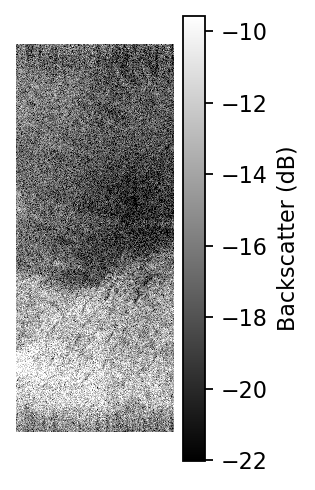

In [9]:
if r.status_code != 200:
    raise RuntimeError(f"Fetch failed: HTTP {r.status_code}")

with MemoryFile(r.content) as mem:
    with mem.open() as ds:
        arr = ds.read(1)
        prof = ds.profile
        nodata_value = ds.nodata

raw_valid_mask = np.isfinite(arr)
if nodata_value is not None:
    raw_valid_mask &= ~np.isclose(arr, nodata_value)

# Extra safety for BIOMASS-style nodata values such as -9999.
raw_valid_mask &= arr > -9990

valid = arr[raw_valid_mask]
if valid.size == 0:
    raise RuntimeError("No valid pixels found after nodata masking.")

print("Shape:", arr.shape)
print("CRS:", prof.get("crs"))
print("Transform:", prof.get("transform"))
print("Nodata:", nodata_value)
print("Valid Min/Max:", float(valid.min()), float(valid.max()))

h, w = arr.shape
fig_w = 2
fig_h = max(3, min(10, fig_w * (h / w)))  # keep the tall aspect but readable

# Convert only valid positive pixels to dB. Invalid/nodata pixels stay as NaN.
arr_for_db = arr.astype("float32")
arr_for_db[~raw_valid_mask] = np.nan

positive_mask = np.isfinite(arr_for_db) & (arr_for_db > 0)
arr_db = np.full(arr_for_db.shape, np.nan, dtype="float32")
arr_db[positive_mask] = 20 * np.log10(arr_for_db[positive_mask])  # magnitude -> dB

valid_db = arr_db[np.isfinite(arr_db)]
if valid_db.size == 0:
    raise RuntimeError("No valid positive pixels found for dB visualization.")

vmin, vmax = np.nanpercentile(valid_db, (2, 98))

plt.figure(figsize=(fig_w, fig_h), dpi=160)
im = plt.imshow(np.ma.masked_invalid(arr_db), cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")
plt.colorbar(im, label="Backscatter (dB)", shrink=0.6)
plt.axis("off")
plt.tight_layout()

## Using Rasterio for Data Access

The below cell shows another method to load the data directly with Rasterio by passing the token in GDAL HTTP headers.

In [10]:
# Works if your GDAL/Rasterio build supports HTTP headers with /vsicurl/.
# This reads the raster directly and also inspects its GCP-based georeferencing.
rio_env = rasterio.Env(GDAL_HTTP_HEADERS=f"Authorization: Bearer {token}")
with rio_env:
    with rasterio.open(asset_href) as ds:
        arr = ds.read(1)
        prof = ds.profile
        gcps_list, gcp_crs = ds.gcps
        nodata_value = ds.nodata

        valid_mask = np.isfinite(arr)
        if nodata_value is not None:
            valid_mask &= ~np.isclose(arr, nodata_value)
        # Extra safety for BIOMASS-style nodata values such as -9999.
        valid_mask &= arr > -9990
        valid = arr[valid_mask]

        print("Shape:", arr.shape)
        print("CRS:", ds.crs)
        print("Nodata:", nodata_value)
        print("GCP count:", len(gcps_list))
        print("GCP CRS:", gcp_crs)
        print("Transform:", ds.transform)
        if valid.size:
            print("Valid Min/Max:", float(valid.min()), float(valid.max()))
        else:
            print("Valid Min/Max: no valid pixels found after nodata masking")

        # Print only a few GCPs so the notebook output stays readable.
        print("First GCPs:", gcps_list[:5])


Shape: (6336, 2569)
CRS: None
Nodata: -9999.0
GCP count: 35
GCP CRS: EPSG:4979
Transform: | 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|
Valid Min/Max: 0.02200109139084816 0.6571391820907593
First GCPs: [GroundControlPoint(row=0.0, col=0.0, x=-136.19234166504052, y=-77.71337129822969, z=1484.785812531598, id='1', info=''), GroundControlPoint(row=2000.0, col=0.0, x=-137.14868695186692, y=-78.0569468389316, z=1235.0607895627618, id='2', info=''), GroundControlPoint(row=4000.0, col=0.0, x=-138.15923293336834, y=-78.3971883873256, z=974.8832997437567, id='3', info=''), GroundControlPoint(row=6000.0, col=0.0, x=-139.2269063892826, y=-78.73410351331279, z=722.0763132562861, id='4', info=''), GroundControlPoint(row=6335.0, col=0.0, x=-139.41126451998605, y=-78.79025033920206, z=684.8043237421662, id='5', info='')]



## Reprojecting the Level 1B Raster Using GCPs

The Level 1B raster may show `CRS: None`, but that does not mean it is ungeoreferenced. In this product, the spatial reference is stored through **GCPs: Ground Control Points**. These points link image row/column locations to real-world map coordinates.

For raster analysis, avoid using `EPSG:4326` as the output grid unless you specifically need a latitude/longitude product. A projected CRS is usually better because the pixel size is measured in meters and the output grid is more suitable for distance, area, resampling, and raster alignment.

The next cell estimates a suitable UTM CRS from the GCP locations. You can override `dst_crs` manually if your study area requires a specific analysis grid.

In [11]:
# Use the GCPs embedded in the raster for source georeferencing.
# The raster can have ds.crs == None but still be georeferenced through ds.gcps.

src_arr = arr.copy()
src_height, src_width = src_arr.shape

if not gcps_list:
    raise RuntimeError("No GCPs found in the raster. Cannot reproject without source georeferencing.")

if gcp_crs is None:
    raise RuntimeError("GCPs were found, but their CRS is missing. Cannot safely reproject.")

print("Source raster CRS:", prof.get("crs"))
print("Source raster transform:", prof.get("transform"))
print("GCP count:", len(gcps_list))
print("GCP CRS:", gcp_crs)
print("First GCP:", gcps_list[0])

Source raster CRS: None
Source raster transform: | 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|
GCP count: 35
GCP CRS: EPSG:4979
First GCP: GroundControlPoint(row=0.0, col=0.0, x=-136.19234166504052, y=-77.71337129822969, z=1484.785812531598, id='1', info='')


In [12]:
def estimate_utm_crs_from_gcps(gcps_list, gcp_crs):
    """Estimate a local UTM CRS from the center of the raster GCP coordinates."""
    xs = [gcp.x for gcp in gcps_list]
    ys = [gcp.y for gcp in gcps_list]

    # Convert the GCP coordinates to lon/lat so we can choose a UTM zone.
    crs_obj = rasterio.crs.CRS.from_user_input(gcp_crs)
    if crs_obj.to_epsg() == 4326 or crs_obj.is_geographic:
        lons, lats = xs, ys
    else:
        lons, lats = transform(crs_obj, "EPSG:4326", xs, ys)

    lon = float(np.nanmean(lons))
    lat = float(np.nanmean(lats))

    zone = int((lon + 180) // 6) + 1
    epsg = 32600 + zone if lat >= 0 else 32700 + zone
    return f"EPSG:{epsg}", lon, lat, zone


# Recommended: use a projected CRS for raster/array processing.
# You can replace this with a project-specific CRS if you already have one.
dst_crs, center_lon, center_lat, utm_zone = estimate_utm_crs_from_gcps(gcps_list, gcp_crs)

print("Approximate raster center lon/lat:", center_lon, center_lat)
print("Estimated UTM zone:", utm_zone)
print("Selected destination CRS:", dst_crs)

# Build a clean destination grid directly from the source GCPs.
dst_transform, dst_width, dst_height = calculate_default_transform(
    src_crs=gcp_crs,
    dst_crs=dst_crs,
    width=src_width,
    height=src_height,
    gcps=gcps_list
)

# Build the valid-data mask from the raw raster before reprojection.
profile_nodata = prof.get("nodata")
if profile_nodata is None:
    profile_nodata = -9999.0

warp_nodata = np.float32(profile_nodata)
src_data = src_arr.astype("float32")

raw_valid_mask = np.isfinite(src_data)
raw_valid_mask &= ~np.isclose(src_data, warp_nodata)

# Extra safety for BIOMASS-style nodata values such as -9999.
raw_valid_mask &= src_data > -9990

if not np.any(raw_valid_mask):
    raise RuntimeError("No valid source pixels found after nodata masking.")

# Reproject the raster values using an internal finite nodata marker.
src_data_for_warp = np.where(raw_valid_mask, src_data, warp_nodata).astype("float32")

reprojected_warp = np.full(
    (dst_height, dst_width),
    warp_nodata,
    dtype="float32"
)

reproject(
    source=src_data_for_warp,
    destination=reprojected_warp,
    gcps=gcps_list,
    src_crs=gcp_crs,
    src_nodata=warp_nodata,
    dst_transform=dst_transform,
    dst_crs=dst_crs,
    dst_nodata=warp_nodata,
    init_dest_nodata=True,
    resampling=Resampling.nearest
)

# Reproject the raw valid-data mask to the same output grid.
# This keeps invalid areas invalid after reprojection instead of allowing them
# to become finite values during the dB conversion.
src_valid_u8 = raw_valid_mask.astype("uint8")
reprojected_valid_u8 = np.zeros((dst_height, dst_width), dtype="uint8")

reproject(
    source=src_valid_u8,
    destination=reprojected_valid_u8,
    gcps=gcps_list,
    src_crs=gcp_crs,
    src_nodata=0,
    dst_transform=dst_transform,
    dst_crs=dst_crs,
    dst_nodata=0,
    init_dest_nodata=True,
    resampling=Resampling.nearest
)

reprojected_valid_mask = reprojected_valid_u8 == 1
reprojected_valid_mask &= np.isfinite(reprojected_warp)
reprojected_valid_mask &= ~np.isclose(reprojected_warp, warp_nodata)
reprojected_valid_mask &= reprojected_warp > -9990

# Keep invalid output pixels as NaN for downstream analysis and plotting.
reprojected = reprojected_warp.astype("float32")
reprojected[~reprojected_valid_mask] = np.nan
reprojected_ma = np.ma.masked_invalid(reprojected)

print("Destination CRS:", dst_crs)
print("Reprojected shape:", reprojected.shape)
print("Source invalid/nodata pixels:", int((~raw_valid_mask).sum()))
print("Output invalid/NaN pixels:", int((~reprojected_valid_mask).sum()))
print("Output valid pixels:", int(reprojected_valid_mask.sum()))
print("Destination transform:", dst_transform)

Approximate raster center lon/lat: -136.6401415960174 -78.49629318887443
Estimated UTM zone: 8
Selected destination CRS: EPSG:32708
Destination CRS: EPSG:32708
Reprojected shape: (6820, 5507)
Source invalid/nodata pixels: 0
Output invalid/NaN pixels: 19780604
Output valid pixels: 17777136
Destination transform: | 22.43, 0.00, 404331.00|
| 0.00,-22.43, 1373346.87|
| 0.00, 0.00, 1.00|


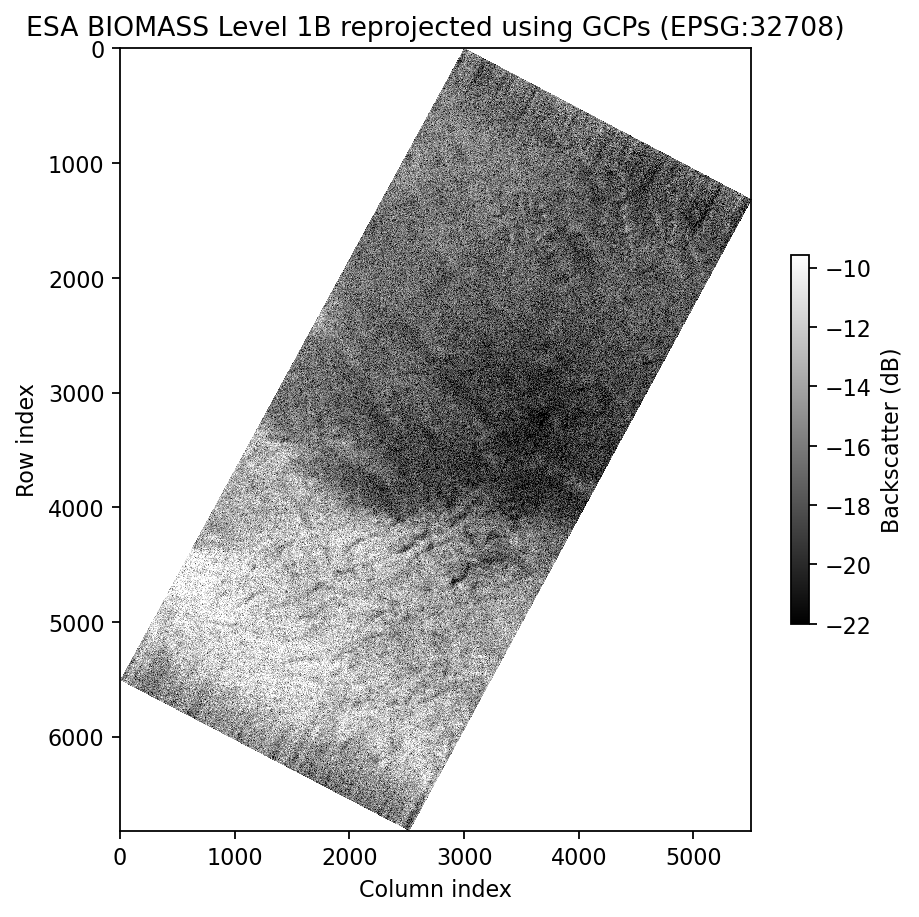

Saved reprojected raster to: biomass_level1b_reprojected_gcps_epsg32708.tif


In [13]:
# Visualize and save the GCP-based reprojected raster with invalid areas kept as NaN.
valid = reprojected[np.isfinite(reprojected)]
if valid.size == 0:
    raise RuntimeError("No valid pixels found after reprojection.")

# Convert only valid positive pixels to dB. Invalid/nodata pixels remain NaN.
positive_mask = np.isfinite(reprojected) & (reprojected > 0)

reprojected_db = np.full(reprojected.shape, np.nan, dtype="float32")
reprojected_db[positive_mask] = 20 * np.log10(reprojected[positive_mask])

valid_db = reprojected_db[np.isfinite(reprojected_db)]
if valid_db.size == 0:
    raise RuntimeError("No valid positive pixels found for dB visualization.")

vmin, vmax = np.nanpercentile(valid_db, (2, 98))

plt.figure(figsize=(6, 8), dpi=160)
im = plt.imshow(
    np.ma.masked_invalid(reprojected_db),
    cmap="gray",
    vmin=vmin,
    vmax=vmax,
    interpolation="nearest"
)
plt.colorbar(im, label="Backscatter (dB)", shrink=0.3)
plt.title(f"ESA BIOMASS Level 1B reprojected using GCPs ({dst_crs})")
plt.xlabel("Column index")
plt.ylabel("Row index")
plt.tight_layout()
plt.show()

safe_crs_name = dst_crs.lower().replace(":", "")
reprojected_path = f"biomass_level1b_reprojected_gcps_{safe_crs_name}.tif"

dst_profile = prof.copy()
dst_profile.update(
    driver="GTiff",
    crs=dst_crs,
    transform=dst_transform,
    width=dst_width,
    height=dst_height,
    count=1,
    dtype="float32",
    nodata=np.nan,
    compress="deflate"
)

# Remove GCP metadata from the output profile because the output is now grid-georeferenced
# with a real CRS + affine transform.
dst_profile.pop("gcps", None)
dst_profile.pop("gcp_crs", None)

with rasterio.open(reprojected_path, "w", **dst_profile) as dst:
    dst.write(reprojected.astype("float32"), 1)

print("Saved reprojected raster to:", reprojected_path)

## Downloading File Locally

Here we define a helper function to save authenticated downloads to disk for later use.

In [14]:
def save_auth_file(url: str, token: str, out_path: str, chunk: int = 1 << 20) -> str:
    headers = {"Authorization": f"Bearer {token}"}
    with requests.get(url, headers=headers, stream=True) as resp:
        resp.raise_for_status()
        with open(out_path, "wb") as f:
            for part in resp.iter_content(chunk_size=chunk):
                if part:
                    f.write(part)
    return out_path

# Example:
save_auth_file(asset_href, token, asset_href.split('/')[-1])


'bio_s2_dgm__1s_20251212t011620_20251212t011641_t_g01_m01_c01_t001_f224_i_abs.tiff'

The example ESA BIOMASS Level1b tile is successfully downloaded locally. 